In [1]:
# M3 - Random Forest + Target Encoding + Optuna Tuning
#
# ⚠️  DÉPENDANCES REQUISES :
# pip install category_encoders optuna
#
# Changements majeurs par rapport à la v1 :
# - ✅ OneHotEncoder → TargetEncoder (categorical_encoders)
#   → Plus compact, pas d'explosion dimensionnelle
#   → Mieux adapté au RandomForest
# - ✅ RandomizedSearchCV → Optuna avec pruning et early stopping
#   → Recherche bayésienne + arrêt automatique si pas d'amélioration
#
# 1. IMPORTATIONS POUR LE M3 (Sélection + Random Forest)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing classique
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

# Outils pour la sélection de variables et l'optimisation
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned


/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# 2. CHARGEMENT DES DONNÉES ET PREPARATION DE LA TARGET

def advanced_feature_engineering(data):
    """
    Applique les transformations métiers sur le jeu de données.
    Note : L'encodage ordinal et les variables combinées (TotalSF, TotalBath, IsRemodeled)
    sont inspirés de stratégies performantes trouvées sur les notebooks publics de Kaggle.
    """
    df = data.copy()

    # --- A. CRÉATION DE VARIABLES (Inspiration Kaggle) ---
    # 1. Surface totale (Sous-sol + RDC + 1er étage)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # 2. Salles de bain totales (Les "HalfBath" comptent pour 0.5)
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']

    # 3. Rénovation (Flag binaire : 1 si rénové, 0 sinon)
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

    # --- B. ENCODAGE ORDINAL (Inspiration Kaggle) ---
    # On force la qualité en chiffres pour créer une hiérarchie stricte pour le Random Forest
    ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
    quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, np.nan: 0}

    for col in ordinal_cols:
        if col in df.columns:
            df[col] = df[col].map(quality_map)

    # --- C. GESTION DES DATES (Calcul des âges) ---
    df['AgeBuilt'] = df['YrSold'] - df['YearBuilt']
    df['AgeRemodAdd'] = df['YrSold'] - df['YearRemodAdd']
    df['AgeGarage'] = df['YrSold'] - df['GarageYrBlt']

    # On supprime les anciennes dates brutes qui perturbent le modèle
    df = df.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1)

    return df


# --- 1. Chargement brut ---
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# --- 2. Nettoyage des Outliers (SUR LE TRAIN UNIQUEMENT) ---
# Suppression des 2 transactions aberrantes repérées visuellement (>4000 sqft & <300000$)
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

# --- 3. Feature Engineering ---
train_df = advanced_feature_engineering(train_df)
test_df = advanced_feature_engineering(test_df)

# --- 4. Séparation X et y ---
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [12]:
# 3. CRÉATION DU PREPROCESSOR (Optimisé : KNNImputer + Séparation des Catégories)
# Redétection dynamique des colonnes après les changements de l'étape 2
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# 1. Identification des "faux manquants" (les variables où NaN = "Il n'y en a pas")
cat_none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                     'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                     'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                     'BsmtFinType2', 'MasVnrType']

# Les autres catégorielles (les "vrais manquants")
cat_freq_features = [col for col in categorical_features if col not in cat_none_features]

# 2. Pipeline Numérique : Utilisation du KNNImputer pour estimer les valeurs manquantes intelligemment
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

# 3. Pipeline Catégorielle 1 : Remplacement par "None" pour les absences de structure
cat_none_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value'))
])

# 4. Pipeline Catégorielle 2 : Remplacement classique par la valeur la plus fréquente
cat_freq_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value'))
])

# 5. L'assembleur final (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_none', cat_none_transformer, cat_none_features),
        ('cat_freq', cat_freq_transformer, cat_freq_features)
    ])

In [13]:
# 3bis. DIAGNOSTIC DU TARGET ENCODING
# Affichage des colonnes catégorielles et vérification du preprocessing

print("=" * 60)
print("DIAGNOSTIC DU PREPROCESSING (Target Encoding)")
print("=" * 60)
print(f"\n📊 Variables numériques : {len(numeric_features)}")
print(f"   {list(numeric_features)[:5]}... (affichage tronqué)\n")

print(f"📂 Variables catégorielles : {len(categorical_features)}")
for col in categorical_features:
    card = X_train[col].nunique()
    print(f"   {col:20} → cardinalité: {card:3} (top: {X_train[col].value_counts().index[0]})")

print(f"\n✔️  Target Encoding va traduire chaque catégorie en score numérique")
print(f"   (moyenne conditionnelle de SalePrice Log avec régularisation smoothing=10)")
print("=" * 60)

DIAGNOSTIC DU PREPROCESSING (Target Encoding)

📊 Variables numériques : 48
   ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']... (affichage tronqué)

📂 Variables catégorielles : 34
   MSZoning             → cardinalité:   5 (top: RL)
   Street               → cardinalité:   2 (top: Pave)
   Alley                → cardinalité:   2 (top: Grvl)
   LotShape             → cardinalité:   4 (top: Reg)
   LandContour          → cardinalité:   4 (top: Lvl)
   Utilities            → cardinalité:   2 (top: AllPub)
   LotConfig            → cardinalité:   5 (top: Inside)
   LandSlope            → cardinalité:   3 (top: Gtl)
   Neighborhood         → cardinalité:  25 (top: NAmes)
   Condition1           → cardinalité:   9 (top: Norm)
   Condition2           → cardinalité:   8 (top: Norm)
   BldgType             → cardinalité:   5 (top: 1Fam)
   HouseStyle           → cardinalité:   8 (top: 1Story)
   RoofStyle            → cardinalité:   6 (top: Gable)
   RoofMatl            

In [14]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M3)

# Étape A : Le Filtre Lasso
# SelectFromModel va utiliser un LassoCV en interne. Il gardera uniquement les variables dont le coefficient n'a pas été réduit à 0.
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : Le Modèle Random Forest (Artillerie lourde)
# On initialise une Forêt Aléatoire de base
rf_model = RandomForestRegressor(random_state=42)

# Étape C : Assemblage de la Super Pipeline
pipeline_m3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_model)
])

# Étape D : Optimisation avec Optuna (plus intelligent que RandomizedSearchCV)
def objective(trial):
    """
    Fonction objective pour Optuna : teste différentes combos d'hyperparamètres
    et retourne le RMSE moyen en validation croisée.

    Implémentation avec boucle CV manuelle pour pouvoir "report" et permettre
    le pruning par Optuna (ex: MedianPruner). On utilise KFold pour générer
    des scores intermédiaires.
    """
    # Optuna suggère les hyperparamètres
    n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    # Créer une nouvelle pipeline avec ces hyperparamètres
    rf_model_trial = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    pipeline_trial = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('rf', rf_model_trial)
    ])

    # Boucle CV manuelle pour pouvoir reporter les scores de chaque fold
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline_trial.fit(X_tr, y_tr)
        preds = pipeline_trial.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        neg_rmse = -rmse  # on garde la convention 'plus grand = meilleur'
        fold_scores.append(neg_rmse)

        # Report pour le pruner d'Optuna
        trial.report(neg_rmse, step=fold_idx)
        if trial.should_prune():
            raise TrialPruned()

    # Retourner la moyenne négative du RMSE (direction maximize)
    return float(np.mean(fold_scores))


# Étape E : Lancement de l'étude Optuna
print("Lancement de l'optimisation Optuna (recherche bayésienne intelligente + pruning)...")
print("Cela va tester jusqu'à 50 combinaisons mais pourra s'arrêter plus tôt si inutile...\n")

# Sampler Bayésien (TPE = Tree-structured Parzen Estimator) et pruner
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_warmup_steps=5)

# Callback pour stopper l'étude si pas d'amélioration sur N trials consécutifs
def stop_if_no_improvement_factory(patience=10):
    state = {'best_value': None, 'no_improve': 0}

    def _callback(study, trial):
        # study.best_value suit la direction (ici maximize)
        if state['best_value'] is None or study.best_value > state['best_value']:
            state['best_value'] = study.best_value
            state['no_improve'] = 0
        else:
            state['no_improve'] += 1

        if state['no_improve'] >= patience:
            print(f"Aucun progrès depuis {patience} essais — arrêt de l'étude Optuna.")
            study.stop()

    return _callback

early_stop_callback = stop_if_no_improvement_factory(patience=10)

study = optuna.create_study(
    direction='maximize',  # On maximise car on retourne neg_rmse
    sampler=sampler,
    pruner=pruner
)

# Lancement de l'optimisation avec callback d'arrêt anticipé
study.optimize(objective, n_trials=50, callbacks=[early_stop_callback], show_progress_bar=True)

print("-" * 50)
print("Optimisation terminée !")
print(f"Meilleur score CV (neg_rmse) : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres trouvés :\n{study.best_params}")
print("-" * 50)

# Réentraîner le meilleur modèle avec les meilleurs paramètres
best_params = study.best_params
rf_best = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42,
    n_jobs=-1
)

best_m3_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_best)
])

# Fit sur tout le train set
best_m3_pipeline.fit(X_train, y_train)

# Évaluation sur le Train Set
y_pred_train = best_m3_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE (Log) sur le Train Set : {rmse_train:.4f}")

[I 2026-05-24 12:18:52,837] A new study created in memory with name: no-name-f359dc7a-56e8-4188-a875-fb09f46531b8


Lancement de l'optimisation Optuna (recherche bayésienne intelligente + pruning)...
Cela va tester jusqu'à 50 combinaisons mais pourra s'arrêter plus tôt si inutile...



Best trial: 0. Best value: -0.135876:   2%|▏         | 1/50 [00:01<01:22,  1.68s/it]

[I 2026-05-24 12:18:54,517] Trial 0 finished with value: -0.13587643106381064 and parameters: {'n_estimators': 200, 'max_depth': 48, 'min_samples_split': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.13587643106381064.


Best trial: 0. Best value: -0.135876:   4%|▍         | 2/50 [00:02<01:09,  1.45s/it]

...

[I 2026-05-24 12:19:58,633] Trial 30 finished with value: -0.13165716141104145 and parameters: {'n_estimators': 250, 'max_depth': 41, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 22 with value: -0.13062356663809924.


Best trial: 22. Best value: -0.130624:  64%|██████▍   | 32/50 [01:08<00:40,  2.24s/it]

[I 2026-05-24 12:20:00,934] Trial 31 finished with value: -0.1308447529727218 and parameters: {'n_estimators': 400, 'max_depth': 24, 'min_samples_split': 4, 'max_features': 'sqrt'}. Best is trial 22 with value: -0.13062356663809924.


Best trial: 22. Best value: -0.130624:  66%|██████▌   | 33/50 [01:10<00:36,  2.13s/it]


[I 2026-05-24 12:20:03,156] Trial 32 finished with value: -0.13126537753499698 and parameters: {'n_estimators': 400, 'max_depth': 23, 'min_samples_split': 6, 'max_features': 'sqrt'}. Best is trial 22 with value: -0.13062356663809924.
Aucun progrès depuis 10 essais — arrêt de l'étude Optuna.
--------------------------------------------------
Optimisation terminée !
Meilleur score CV (neg_rmse) : -0.1306
Meilleurs hyperparamètres trouvés :
{'n_estimators': 500, 'max_depth': 17, 'min_samples_split': 4, 'max_features': 'sqrt'}
--------------------------------------------------
RMSE (Log) sur le Train Set : 0.0574


In [15]:
# 5. GÉNÉRATION DE LA SOUMISSION KAGGLE

# On prédit avec le meilleur modèle trouvé
preds_log_m3 = best_m3_pipeline.predict(X_test)
preds_dollars_m3 = np.expm1(preds_log_m3) # Retour au prix en dollars

submission_m3 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m3
})

fichier_soumission = 'M3_RandomForest_Submission.csv'
submission_m3.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M3_RandomForest_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


/tmp/ipykernel_124201/3550856320.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Variable', palette='viridis')


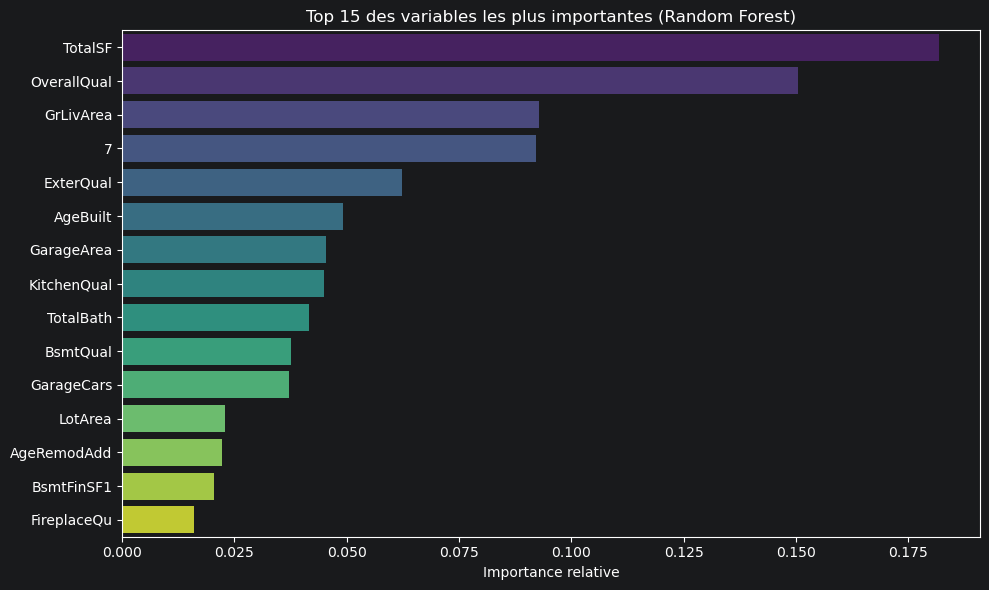

In [18]:
# 1. Récupération des noms originaux à la sortie du preprocessor
feature_names = best_m3_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Le Lasso a filtré des variables : on récupère uniquement celles qui sont passées
lasso_mask = best_m3_pipeline.named_steps['selector'].get_support()
selected_feature_names = feature_names[lasso_mask]

# 3. Récupération des scores d'importance calculés par le Random Forest
importances = best_m3_pipeline.named_steps['rf'].feature_importances_

# 4. Création d'un tableau propre
importance_df = pd.DataFrame({
    'Variable': selected_feature_names,
    'Importance': importances
})

# 5. Nettoyage esthétique : on efface les préfixes disgracieux de Scikit-Learn
importance_df['Variable'] = importance_df['Variable'].str.replace(r'^(num|cat_none|cat_freq)__', '', regex=True)

# 6. Tri et sélection du Top 15
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 7. Affichage du graphique final
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Variable', palette='viridis')
plt.title('Top 15 des variables les plus importantes (Random Forest)')
plt.xlabel('Importance relative')
plt.ylabel('')
plt.tight_layout()
plt.show()